In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('student-mat.csv', sep=';')
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [5]:
df.columns.tolist()

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'Pstatus',
 'Medu',
 'Fedu',
 'Mjob',
 'Fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'Dalc',
 'Walc',
 'health',
 'absences',
 'G1',
 'G2',
 'G3']

In [6]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [7]:
#null count values per column 
df.isnull().sum() 

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [14]:
#datatype count values 
df.dtypes.value_counts()


Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

In [8]:
#to see only integer datatype columns(int64)
df.select_dtypes(include='int64').columns

Index(['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel',
       'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2',
       'G3'],
      dtype='object')

In [9]:
#to see only objexct/text datatype columns
df.select_dtypes(include='object').columns

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [10]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [11]:
df.isnull().sum().sum()

0

In [12]:
#filters and shows only columns that have at least 1 missing value
df.isnull().sum()[df.isnull().sum() > 0]

Series([], dtype: int64)

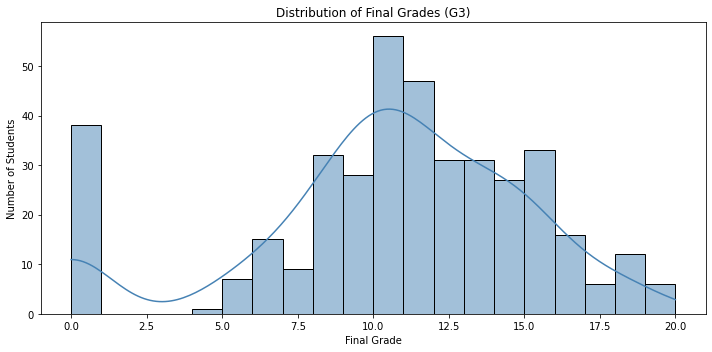

Average Final Grade: 10.42
Highest Grade: 20
Lowest Grade: 0


In [13]:
plt.figure(figsize=(10, 5))
sns.histplot(df['G3'], bins=20, color='steelblue', kde=True)
plt.title('Distribution of Final Grades (G3)')
plt.xlabel('Final Grade')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

print("Average Final Grade:", round(df['G3'].mean(), 2))
print("Highest Grade:", df['G3'].max())
print("Lowest Grade:", df['G3'].min())

In [14]:
df['Pass'] = (df['G3'] >= 10).astype(int)

print("Pass/Fail Distribution:")
print(df['Pass'].value_counts())
print()
print(f"Pass: {df['Pass'].sum()} students")
print(f"Fail: {(df['Pass'] == 0).sum()} students")

Pass/Fail Distribution:
1    265
0    130
Name: Pass, dtype: int64

Pass: 265 students
Fail: 130 students


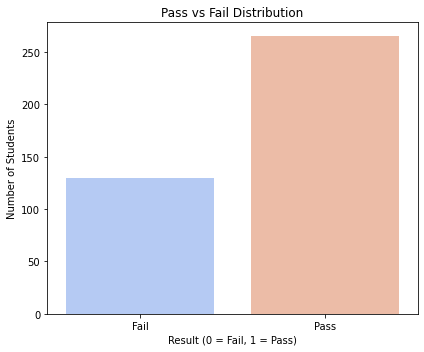

In [15]:
plt.figure(figsize=(6, 5))
sns.countplot(x='Pass', data=df, palette='coolwarm')
plt.title('Pass vs Fail Distribution')
plt.xlabel('Result (0 = Fail, 1 = Pass)')
plt.ylabel('Number of Students')
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.tight_layout()
plt.show()

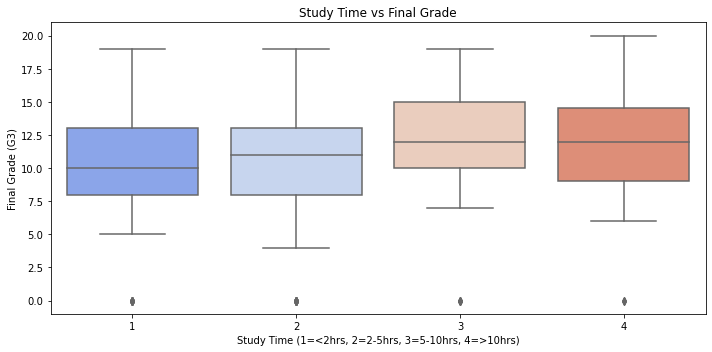

In [16]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='studytime', y='G3', data=df, palette='coolwarm')
plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time (1=<2hrs, 2=2-5hrs, 3=5-10hrs, 4=>10hrs)')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()

In [17]:
df['failures'].unique()

array([0, 3, 2, 1], dtype=int64)

In [18]:
df['failures'].value_counts()

0    312
1     50
2     17
3     16
Name: failures, dtype: int64

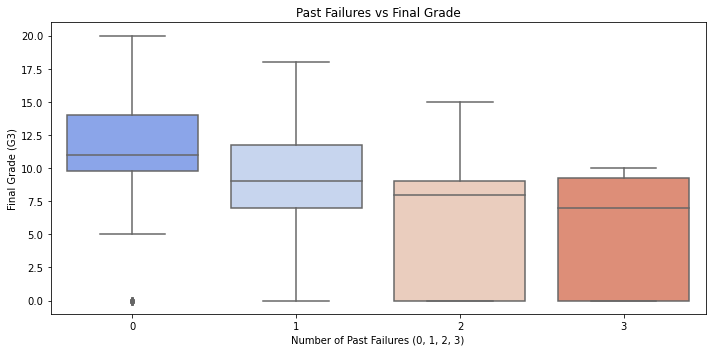

In [19]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='failures', y='G3', data=df, palette='coolwarm')
plt.title('Past Failures vs Final Grade')
plt.xlabel('Number of Past Failures (0, 1, 2, 3)')
plt.ylabel('Final Grade (G3)')
plt.tight_layout()
plt.show()


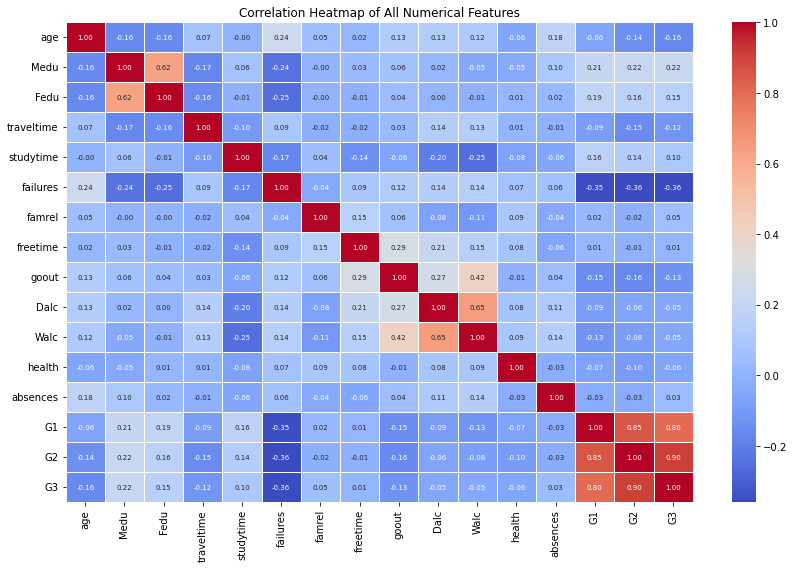

In [20]:
plt.figure(figsize=(12, 8))
numeric_df = df.select_dtypes(include='int64')
correlation = numeric_df.corr()

sns.heatmap(correlation, annot=True, fmt='.2f', 
            cmap='coolwarm', linewidths=0.5, 
            annot_kws={'size': 7})
plt.title('Correlation Heatmap of All Numerical Features')
plt.tight_layout()
plt.show()

In [21]:
# Select features for prediction
features = ['studytime', 'failures', 'absences', 
            'Medu', 'Fedu', 'goout', 'Dalc', 'Walc',
            'G1', 'G2', 'higher', 'internet', 'romantic']

X = df[features]
y = df['Pass']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures selected:")
print(features)

Features shape: (395, 13)
Target shape: (395,)

Features selected:
['studytime', 'failures', 'absences', 'Medu', 'Fedu', 'goout', 'Dalc', 'Walc', 'G1', 'G2', 'higher', 'internet', 'romantic']


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X = X.copy()  #already created X in feature selection : X = df['features']
X['higher'] = le.fit_transform(X['higher'])
X['internet'] = le.fit_transform(X['internet'])
X['romantic'] = le.fit_transform(X['romantic'])

print("Encoding done!")
print(X[['higher', 'internet', 'romantic']].value_counts())

Encoding done!
higher  internet  romantic
1       1         0           207
                  1           106
        0         0            47
                  1            15
0       1         1            10
                  0             6
        0         0             3
                  1             1
dtype: int64


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
                                    X, y, 
                                    test_size=0.2, 
                                    random_state=42, 
                                    stratify = y)
#stratify to maintan the perfect ratio to avoid imbalance -- completely optional
print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

#below is to verify pass/fail ratio maintained or not:
print("Original Pass ratio:", round(y.mean(), 2))
print("Training Pass ratio:", round(y_test.mean() , 2))
print("Testing Pass ratio:", round(y_test.mean(), 2))

Training data shape: (316, 13)
Testing data shape: (79, 13)
Training target shape: (316,)
Testing target shape: (79,)
Original Pass ratio: 0.67
Training Pass ratio: 0.67
Testing Pass ratio: 0.67


In [28]:
# Model 1 - Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

print("Logistic Regression trained successfully!")

Logistic Regression trained successfully!


In [29]:
# Model 2 - Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_predictions = dt_model.predict(X_test)

print("Decision Tree trained successfully!")

Decision Tree trained successfully!


In [30]:
# Logistic Regression Evaluation
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print("Accuracy:", round(accuracy_score(y_test, lr_predictions), 2))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_predictions))
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))

LOGISTIC REGRESSION RESULTS
Accuracy: 0.89

Confusion Matrix:
[[25  1]
 [ 8 45]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.96      0.85        26
           1       0.98      0.85      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.91      0.88        79
weighted avg       0.91      0.89      0.89        79



In [31]:
# Decision Tree Evaluation
print("=" * 50)
print("DECISION TREE RESULTS")
print("=" * 50)
print("Accuracy:", round(accuracy_score(y_test, dt_predictions), 2))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))
print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

DECISION TREE RESULTS
Accuracy: 0.86

Confusion Matrix:
[[24  2]
 [ 9 44]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.92      0.81        26
           1       0.96      0.83      0.89        53

    accuracy                           0.86        79
   macro avg       0.84      0.88      0.85        79
weighted avg       0.88      0.86      0.86        79



In [32]:
print("=" * 55)
print("STUDENT PERFORMANCE ANALYSIS - FINAL SUMMARY")
print("=" * 55)

print("\nDATASET:")
print(f"   Total Students    : {len(df)}")
print(f"   Total Features    : 33")
print(f"   Pass Students     : {df['Pass'].sum()}")
print(f"   Fail Students     : {(df['Pass']==0).sum()}")

print("\nKEY FINDINGS FROM ANALYSIS:")
print("   1. Higher study time leads to better final grades")
print("   2. More past failures = lower final grade")
print("   3. G1 and G2 are strongest predictors of G3")
print("   4. Past failures have strongest negative impact")

print("\nMODEL RESULTS:")
print(f"   Logistic Regression Accuracy : 89%")
print(f"   Decision Tree Accuracy       : 86%")
print(f"   Best Model                   : Logistic Regression")

print("\nCONCLUSION:")
print("   Logistic Regression successfully predicts student")
print("   pass/fail outcome with 89% accuracy using 13")
print("   features including grades, study habits and")
print("   social factors!")
print("=" * 55)

STUDENT PERFORMANCE ANALYSIS - FINAL SUMMARY

DATASET:
   Total Students    : 395
   Total Features    : 33
   Pass Students     : 265
   Fail Students     : 130

KEY FINDINGS FROM ANALYSIS:
   1. Higher study time leads to better final grades
   2. More past failures = lower final grade
   3. G1 and G2 are strongest predictors of G3
   4. Past failures have strongest negative impact

MODEL RESULTS:
   Logistic Regression Accuracy : 89%
   Decision Tree Accuracy       : 86%
   Best Model                   : Logistic Regression

CONCLUSION:
   Logistic Regression successfully predicts student
   pass/fail outcome with 89% accuracy using 13
   features including grades, study habits and
   social factors!
